In [1]:
import os
import sys
from urllib.parse import urljoin
from bs4 import BeautifulSoup
import requests
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
!{sys.executable} -m pip install matplotlib seaborn
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
pip install pyarrow


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
PREP_DIR = Path.cwd()  # run with CWD = additional_data_source/opentarget/
sys.path.insert(0, str(PREP_DIR.parent))
from release_paths import resolve_release_root, primary_data_dir

RELEASE_ROOT = resolve_release_root()
DATA_DIR = primary_data_dir(RELEASE_ROOT)
OPENTARGET_OUT = DATA_DIR / "disgenet" / "OpenTarget" / "OpenTarget_disease_protein_associations.csv"
OPENTARGET_OUT.parent.mkdir(parents=True, exist_ok=True)
data_path = str(DATA_DIR) + os.sep

In [5]:
# Run from additional_data_source/opentarget/ — inputs here; outputs -> primary_data_prep/data/


In [6]:
# ==== 1. Configuration ====
BASE_URL = "https://ftp.ebi.ac.uk/pub/databases/opentargets/platform/25.09/output/association_overall_direct/"
SAVE_DIR = "opentargets_associations"
os.makedirs(SAVE_DIR, exist_ok=True)

In [7]:
# ==== 2. List *.parquet files in GCS folder ====
def list_parquet_files(url):
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")
    files = []

    for link in soup.find_all("a"):
        href = link.get("href")
        if href.endswith(".parquet"):
            files.append(urljoin(url, href))
    return files

files = list_parquet_files(BASE_URL)
print(f"Found {len(files)} files")

Found 20 files


In [8]:
# ==== 3. Download each file ====
def download_file(url, save_dir):
    name = url.split("/")[-1]
    path = os.path.join(save_dir, name)
    print(path)
    if not os.path.exists(path):
        print("Downloading:", name)
        r = requests.get(url)
        with open(path, "wb") as f:
            f.write(r.content)
    else:
        print("Already exists:", name)

    return path

# local_files = [download_file(f, SAVE_DIR) for f in files]

In [9]:
# local_files

In [10]:
local_files = os.listdir("inputs/opentargets_associations")
local_files

['part-00011-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00006-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00016-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00001-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00017-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00000-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00010-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00007-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00009-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00015-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00002-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00012-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00019-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.parquet',
 'part-00005-115d4937-47d3-4de3-a70b-eb4fc9f78010-c000.snappy.pa

In [11]:
parquet_dir = "inputs/opentargets_associations"


In [13]:
# ==== 4. Read and merge all parquet files ====
# dfs = [pd.read_parquet(parquet_dir + "/" + f) for f in local_files]
# ot_assoc = pd.concat(dfs, ignore_index=True)
# print("Final dataset shape:", ot_assoc.shape)
# ot_assoc.to_csv("inputs/OpenTargets_associations_merged.csv")

ot_assoc = pd.read_csv("inputs/OpenTargets_associations_merged.csv")


In [14]:
ot_assoc.head(3)

,Unnamed: 0,diseaseId,targetId,score,evidenceCount
0,0,HP_0001518,ENSG00000006071,0.266097,1
1,1,HP_0001518,ENSG00000054983,0.332622,2
2,2,HP_0001518,ENSG00000068078,0.340013,1


In [15]:
ot_assoc.evidenceCount.describe()

count    3.987332e+06
mean     7.603350e+00
std      1.373098e+02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      5.134600e+04
Name: evidenceCount, dtype: float64

In [16]:
ot_assoc.score.min(), ot_assoc.score.max()

(np.float64(0.0007902492030084), np.float64(0.9133450071938024))

In [17]:
len(ot_assoc), len(ot_assoc.diseaseId.unique())

(3987332, 22778)

In [18]:
ot_assoc.head(3)

,Unnamed: 0,diseaseId,targetId,score,evidenceCount
0,0,HP_0001518,ENSG00000006071,0.266097,1
1,1,HP_0001518,ENSG00000054983,0.332622,2
2,2,HP_0001518,ENSG00000068078,0.340013,1


In [19]:
ot_score_threshold = 0.1
ot_assoc = ot_assoc[ot_assoc.score>=ot_score_threshold] #change here for difference comparison between score =0.1 and 0.3

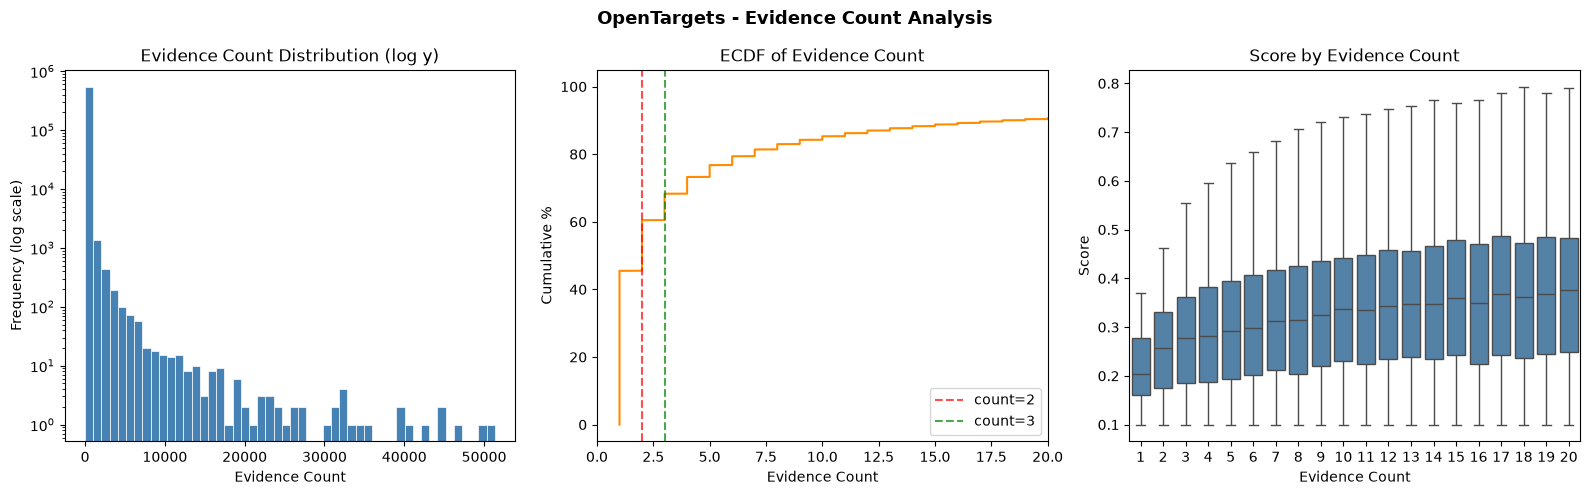

count    551397.000000
mean         28.138722
std         364.317697
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max       51346.000000
Name: evidenceCount, dtype: float64

Proportion with count=1:  45.5%
Proportion with count>=2: 54.5%
Proportion with count>=3: 39.5%


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histogram (log-scale y-axis to show long tail)
axes[0].hist(ot_assoc['evidenceCount'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_yscale('log')
axes[0].set_xlabel('Evidence Count')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Evidence Count Distribution (log y)')

# 2. ECDF — cumulative % for threshold choice
sorted_counts = np.sort(ot_assoc['evidenceCount'])
ecdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1].plot(sorted_counts, ecdf * 100, color='darkorange')
axes[1].axvline(x=2, color='red', linestyle='--', alpha=0.7, label='count=2')
axes[1].axvline(x=3, color='green', linestyle='--', alpha=0.7, label='count=3')
axes[1].set_xlabel('Evidence Count')
axes[1].set_ylabel('Cumulative %')
axes[1].set_title('ECDF of Evidence Count')
axes[1].legend()
axes[1].set_xlim(0, 20)  # zoom to head

# 3. Fix: use seaborn boxplot instead of pandas boxplot
import seaborn as sns
count_cap = min(ot_assoc['evidenceCount'].quantile(0.95), 20)
df_plot = ot_assoc[ot_assoc['evidenceCount'] <= count_cap].copy()
df_plot['evidenceCount'] = df_plot['evidenceCount'].astype(int)

sns.boxplot(data=df_plot, x='evidenceCount', y='score', ax=axes[2], color='steelblue')
axes[2].set_xlabel('Evidence Count')
axes[2].set_ylabel('Score')
axes[2].set_title('Score by Evidence Count')

plt.suptitle('OpenTargets - Evidence Count Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print(ot_assoc['evidenceCount'].describe())
print(f"\nProportion with count=1:  {(ot_assoc['evidenceCount']==1).mean():.1%}")
print(f"Proportion with count>=2: {(ot_assoc['evidenceCount']>=2).mean():.1%}")
print(f"Proportion with count>=3: {(ot_assoc['evidenceCount']>=3).mean():.1%}")

In [25]:
ot_assoc['evidenceCount'].max()

np.int64(51346)

In [26]:
len(ot_assoc), len(ot_assoc.diseaseId.unique())

(551397, 18475)

In [27]:
disease_meta = pd.read_parquet("inputs/disease.parquet")
len(disease_meta)

39530

In [28]:
disease_meta.head(4)

,id,code,name,description,dbXRefs,parents,synonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology
0,DOID_0050890,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[UMLS:C5191670, MONDO:0000510, MEDGEN:1682194,...","[MONDO_0019052, MONDO_0021179, MONDO_0024237]",{'hasExactSynonym': ['alpha Synucleinopathies'...,[],[],"[EFO_0006792, EFO_1001050]","[MONDO_0019052, MONDO_0021179, EFO_0009386, MO...","[OTAR_0000020, EFO_0000618, OTAR_0000018]","[MONDO_0000211, MONDO_0016418, MONDO_0014835, ...","{'isTherapeuticArea': False, 'leaf': False, 's..."
1,DOID_10113,http://purl.obolibrary.org/obo/DOID_10113,trypanosomiasis,Infection with protozoa of the genus trypanosoma.,"[MONDO:0000940, NANDO:2200774, ICD10CM:B56, DO...",[MONDO_0002428],{'hasExactSynonym': ['Trypanosoma caused disea...,[],[],"[MONDO_0001444, EFO_0005225, EFO_0008559]","[EFO_0001067, EFO_0005741, MONDO_0002428]",[EFO_0005741],"[MONDO_0001444, EFO_0005225, EFO_0008559, EFO_...","{'isTherapeuticArea': False, 'leaf': False, 's..."
2,DOID_10718,http://purl.obolibrary.org/obo/DOID_10718,giardiasis,An infection of the small intestine caused by ...,"[MEDGEN:42213, SCTID:10679007, DOID:10718, icd...","[MONDO_0002428, EFO_0009561]","{'hasExactSynonym': ['beaver fever', 'giardias...",[],[],[],"[EFO_0009431, EFO_0001067, MONDO_0043424, EFO_...","[EFO_0010282, EFO_0005741]",[],"{'isTherapeuticArea': False, 'leaf': False, 's..."
3,DOID_13406,http://purl.obolibrary.org/obo/DOID_13406,pulmonary sarcoidosis,Sarcoidosis affecting the lung parenchyma. It ...,"[MONDO:0001708, MESH:D017565, SNOMEDCT:2436900...","[MONDO_0017026, MONDO_0019338]","{'hasExactSynonym': ['pulmonary sarcoidosis', ...",[],[],[EFO_1001232],"[MONDO_0019751, EFO_1001986, EFO_0004244, EFO_...","[OTAR_0000006, OTAR_0000010]",[EFO_1001232],"{'isTherapeuticArea': False, 'leaf': False, 's..."


In [29]:
print(len(ot_assoc), len(ot_assoc.targetId.unique()))
ot_assoc.head(2)

551397 19075


,Unnamed: 0,diseaseId,targetId,score,evidenceCount
0,0,HP_0001518,ENSG00000006071,0.266097,1
1,1,HP_0001518,ENSG00000054983,0.332622,2


In [30]:
unique_targets = ot_assoc['targetId'].dropna().astype(str).unique().tolist()
# remove any non-ENSG (if ids include ENSP etc.)
ensgs = [t for t in unique_targets if t.startswith("ENSG")]
len(ensgs)

19075

In [45]:
# Optional: regenerate Ensembl → gene-symbol mapping via Ensembl REST
# (time-consuming; results already saved as inputs/20260417-EnsemblID-Genename.csv)
# ensembl_lookup = {}
# for i, ensg in enumerate(ensgs):
#     url = f"https://rest.ensembl.org/lookup/id/{ensg}?content-type=application/json"
#     try:
#         r = requests.get(url, headers={"Content-Type": "application/json"})
#         r.raise_for_status()
#         symbol = r.json().get("display_name")
#         ensembl_lookup[ensg] = symbol
#     except Exception as e:
#         ensembl_lookup[ensg] = None
#         print(f"Warning: failed to fetch {ensg} — {e}")
#     if i % 100 == 0:
#         print("progressing at i =", i)
#
# with open("inputs/20260417-EnsemblID-Genename.csv", "w") as f:
#     for ensg, symbol in ensembl_lookup.items():
#         if symbol is not None:
#             f.write(f"{ensg},{symbol}\n")


progressing at i =  0


KeyboardInterrupt: 

In [31]:
ensg_to_symbol = pd.read_csv("inputs/20260417-EnsemblID-Genename.csv", header=None)
ensg_to_symbol.columns = ["EnsemblID", "Genename"]
print(len(ensg_to_symbol))
ensg_to_symbol.head(3)


6


,EnsemblID,Genename
0,ENSG00000006071,ABCC8
1,ENSG00000054983,GALC
2,ENSG00000068078,FGFR3


In [32]:
ot_assoc.head(2)

,Unnamed: 0,diseaseId,targetId,score,evidenceCount
0,0,HP_0001518,ENSG00000006071,0.266097,1
1,1,HP_0001518,ENSG00000054983,0.332622,2


In [33]:
disease_meta.head(2)

,id,code,name,description,dbXRefs,parents,synonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology
0,DOID_0050890,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[UMLS:C5191670, MONDO:0000510, MEDGEN:1682194,...","[MONDO_0019052, MONDO_0021179, MONDO_0024237]",{'hasExactSynonym': ['alpha Synucleinopathies'...,[],[],"[EFO_0006792, EFO_1001050]","[MONDO_0019052, MONDO_0021179, EFO_0009386, MO...","[OTAR_0000020, EFO_0000618, OTAR_0000018]","[MONDO_0000211, MONDO_0016418, MONDO_0014835, ...","{'isTherapeuticArea': False, 'leaf': False, 's..."
1,DOID_10113,http://purl.obolibrary.org/obo/DOID_10113,trypanosomiasis,Infection with protozoa of the genus trypanosoma.,"[MONDO:0000940, NANDO:2200774, ICD10CM:B56, DO...",[MONDO_0002428],{'hasExactSynonym': ['Trypanosoma caused disea...,[],[],"[MONDO_0001444, EFO_0005225, EFO_0008559]","[EFO_0001067, EFO_0005741, MONDO_0002428]",[EFO_0005741],"[MONDO_0001444, EFO_0005225, EFO_0008559, EFO_...","{'isTherapeuticArea': False, 'leaf': False, 's..."


In [34]:
ot_merged = pd.merge(ot_assoc, ensg_to_symbol, left_on="targetId", right_on="EnsemblID", how="inner")
ot_merged.head(2)

,Unnamed: 0,diseaseId,targetId,score,evidenceCount,EnsemblID,Genename
0,0,HP_0001518,ENSG00000006071,0.266097,1,ENSG00000006071,ABCC8
1,1,HP_0001518,ENSG00000054983,0.332622,2,ENSG00000054983,GALC


In [35]:
ot_merged = pd.merge(ot_merged, disease_meta, left_on="diseaseId", right_on="id", how="inner")
ot_merged.head(2)

,Unnamed: 0,diseaseId,targetId,score,evidenceCount,EnsemblID,Genename,id,code,name,...,dbXRefs,parents,synonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology
0,0,HP_0001518,ENSG00000006071,0.266097,1,ENSG00000006071,ABCC8,HP_0001518,http://purl.obolibrary.org/obo/HP_0001518,Small for gestational age,...,"[SNOMEDCT_US:276610007, UMLS:C0235991, UMLS:C0...",[HP_0004325],{'hasExactSynonym': ['Birth weight less than 1...,[],[],[],"[EFO_0000651, HP_0004323, HP_0004325, HP_00015...",[EFO_0000651],[],"{'isTherapeuticArea': False, 'leaf': False, 's..."
1,1,HP_0001518,ENSG00000054983,0.332622,2,ENSG00000054983,GALC,HP_0001518,http://purl.obolibrary.org/obo/HP_0001518,Small for gestational age,...,"[SNOMEDCT_US:276610007, UMLS:C0235991, UMLS:C0...",[HP_0004325],{'hasExactSynonym': ['Birth weight less than 1...,[],[],[],"[EFO_0000651, HP_0004323, HP_0004325, HP_00015...",[EFO_0000651],[],"{'isTherapeuticArea': False, 'leaf': False, 's..."


In [36]:
ot_merged.columns

Index(['Unnamed: 0', 'diseaseId', 'targetId', 'score', 'evidenceCount',
       'EnsemblID', 'Genename', 'id', 'code', 'name', 'description', 'dbXRefs',
       'parents', 'synonyms', 'obsoleteTerms', 'obsoleteXRefs', 'children',
       'ancestors', 'therapeuticAreas', 'descendants', 'ontology'],
      dtype='str')

In [37]:
len(ot_merged)

1068

In [ ]:
ot_merged = ot_merged[["Genename", "score", "EnsemblID", "name","dbXRefs"]]
ot_merged.head(2)

In [ ]:
import pandas as pd
import numpy as np
import ast

def parse_pairs(cell):

    # Actual NaN
    if cell is None:
        return {}

    # numpy array
    if isinstance(cell, np.ndarray):
        cell = cell.tolist()

    # Actual list
    if isinstance(cell, list):
        items = cell

    # string
    elif isinstance(cell, str):
        cell = cell.strip()

        # empty string
        if cell == "":
            return {}

        # string representation of a list
        if cell.startswith("[") and cell.endswith("]"):
            try:
                items = ast.literal_eval(cell)
            except:
                return {}
        else:
            # string like MONDO:..., NANDO:...
            items = [x.strip() for x in cell.split(",")]

    else:
        return {}

    # Parse each item
    result = {}
    for item in items:
        if isinstance(item, str) and ":" in item:
            name, value = item.split(":", 1)
            result[name.strip()] = value.strip()

    return result


parsed_series = ot_merged["dbXRefs"].apply(parse_pairs)

# all_names = set()
# for d in parsed_series:
#     all_names.update(d.keys())

# print("All names:", all_names)

expanded_df = pd.DataFrame(parsed_series.tolist())

ot_assoc_umls = pd.concat([ot_merged.drop(columns=["dbXRefs"]), expanded_df], axis=1)


In [ ]:
ot_assoc_umls.head(3)

In [ ]:
len(ot_assoc_umls)

In [ ]:
ot_assoc_umls.columns

In [ ]:
ot_assoc_umls = ot_assoc_umls[['Genename', 'score', 'EnsemblID', 'name', 'UMLS']]

In [ ]:
ot_assoc_umls.head(5)

In [ ]:
ot_assoc_umls = ot_assoc_umls.drop_duplicates()
len(ot_assoc_umls)

In [ ]:
ot_assoc_umls = ot_assoc_umls.dropna()
len(ot_assoc_umls)

In [ ]:
len(ot_assoc_umls.name.unique())

In [ ]:
len(ot_assoc_umls.EnsemblID.unique())

In [ ]:
# DisGeNET curated table (bundled under inputs/ for this notebook)
disgenet_path = Path("inputs/Authors-curated_gene_disease_associations.tsv")


In [ ]:
df_disgenet = pd.read_csv(disgenet_path, sep="\t", low_memory=False)
df_disgenet = df_disgenet.astype({"geneId": int}).astype({"geneId": str})
print("len df_disgenet:", len(df_disgenet))
df_disgenet.head(3)


In [ ]:
df_disgenet.diseaseName.unique()[:5]

In [ ]:
df_disgenet.diseaseName = df_disgenet.diseaseName.str.lower()

In [ ]:
df_disgenet.head(2)

In [ ]:
ot_assoc_umls.head(2)

In [ ]:
#now calculate the overalap between df_disgenet (score >=0.3) and disgenet (ot_assoc_umls, no score threshold)
disgenet_pairs = df_disgenet[["geneSymbol", "diseaseId", "score"]]
ot_pairs = ot_assoc_umls[["Genename", "UMLS", "score"]]
ot_pairs.columns = ["geneSymbol", "diseaseId", "score"]

In [ ]:
print(len(ot_pairs))
print(len(ot_pairs[ot_pairs.score>=0.3]))
print(len(disgenet_pairs[disgenet_pairs.score>=0.3]))

In [ ]:
ot_pairs.score.describe()

In [ ]:
disgenet_pairs.score.describe()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})

plt.figure(figsize=(8,5))

sns.histplot(disgenet_pairs["score"], 
             label=f"DisGeNET (>=0.3)", 
             kde=True, 
             stat="density", 
             bins=50)

sns.histplot(ot_pairs["score"], 
             label=f"OpenTargets (>={ot_score_threshold})", 
             kde=True, 
             stat="density", 
             bins=50)

plt.legend()
plt.xlabel("Score")
plt.title("Score distribution comparison")
plt.show()

In [ ]:
# plt.figure(figsize=(8,5))

sns.kdeplot(disgenet_pairs["score"], label="DisGeNET (>=0.3)", cut=0)
sns.kdeplot(ot_pairs["score"], label=f"OpenTargets (>={ot_score_threshold})", cut=0)

plt.legend()
plt.xlabel("Score")
plt.title("Score distribution (all associations)")
# Save
plt.savefig(f"score_distribution_all{ot_score_threshold}.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
overlap_pairs = disgenet_pairs.merge(
    ot_pairs,
    on=["geneSymbol", "diseaseId"],
    suffixes=("_disgenet", "_opentarget")
)
print(len(overlap_pairs))
overlap_pairs.head()

In [ ]:
df_plot = pd.concat([
    overlap_pairs[["score_disgenet"]].rename(columns={"score_disgenet": "score"})
        .assign(source="DisGeNET (>=0.3)"),
    overlap_pairs[["score_opentarget"]].rename(columns={"score_opentarget": "score"})
        .assign(source=f"OpenTargets (>={ot_score_threshold})")
])

plt.figure(figsize=(8,5))

sns.kdeplot(data=df_plot, x="score", hue="source", common_norm=False, cut=0)

plt.title("Score distribution (overlapping associations)")
plt.xlabel("Score")
# Save
plt.savefig(f"score_distribution_overlapping{ot_score_threshold}.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
overlap_pairs

In [ ]:
from scipy.stats import gaussian_kde

kde1 = gaussian_kde(overlap_pairs["score_disgenet"])
kde2 = gaussian_kde(overlap_pairs["score_opentarget"])

x = np.linspace(-0.5, 1.5, 2000)

print(np.trapz(kde1(x), x))  # ~1
print(np.trapz(kde2(x), x))  # ~1

In [ ]:


# --- Step 1: find overlapping pairs ---
overlap_pairs = disgenet_pairs.merge(
    ot_pairs,
    on=["geneSymbol", "diseaseId"],
    how="inner"
)

# --- Step 2: find non-overlapping pairs ---
disgenet_only_pairs = disgenet_pairs.merge(
    overlap_pairs[["geneSymbol", "diseaseId"]],
    on=["geneSymbol", "diseaseId"],
    how="left",
    indicator=True
).query('_merge == "left_only"').drop(columns="_merge")

ot_only_pairs = ot_pairs.merge(
    overlap_pairs[["geneSymbol", "diseaseId"]],
    on=["geneSymbol", "diseaseId"],
    how="left",
    indicator=True
).query('_merge == "left_only"').drop(columns="_merge")

# --- Step 3: reshape to long format ---
df_plot = pd.concat([
    disgenet_only_pairs[["score"]].assign(source="DisGeNET (>=0.3)"),
    ot_only_pairs[["score"]].assign(source=f"OpenTargets (>={ot_score_threshold})")
])

# --- Step 4: plot ---
plt.figure(figsize=(8,5))

sns.kdeplot(data=df_plot, x="score", hue="source", common_norm=False, cut=0)

plt.xlabel("Score")
plt.title("Score distribution (non-overlapping associations)")

# Save
plt.savefig(f"score_distribution_non_overlapping{ot_score_threshold}.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import mygene
import pandas as pd

mg = mygene.MyGeneInfo()

genes = ot_assoc_umls.Genename.unique()

result = mg.querymany(
    genes,
    scopes="symbol",
    fields="entrezgene",
    species="human"
)

gene_ncbi_map = pd.DataFrame(result)
print(gene_ncbi_map[["query", "entrezgene"]])


In [ ]:
gene_ncbi_map = gene_ncbi_map[['query', 'entrezgene']]

In [ ]:
gene_ncbi_map.columns = ["Genename", "NCBI_ID"]

In [ ]:
disgenet_diseases = df_disgenet.diseaseName.unique()
ot_diseases = ot_assoc_umls.name.unique()
len([x for x in ot_diseases if not x in disgenet_diseases])

In [ ]:
disgenet_genes = df_disgenet.geneSymbol.unique()
ot_genes = ot_assoc_umls.Genename.unique()
len([x for x in ot_genes if not x in disgenet_genes])

In [ ]:
df_disgenet["pairs"] = df_disgenet["geneSymbol"] + "_" + df_disgenet["diseaseName"]
ot_assoc_umls["pairs"] = ot_assoc_umls["Genename"] + "_" + ot_assoc_umls["name"]
ot_assoc_umls.head(3)

In [ ]:
disgenet_pair_keys = df_disgenet.pairs.unique()
ot_pair_keys = ot_assoc_umls.pairs.unique()
novel_pair_keys = [p for p in ot_pair_keys if not p in disgenet_pair_keys]
ot_novel_rows = ot_assoc_umls[ot_assoc_umls.pairs.isin(novel_pair_keys)]
len(ot_novel_rows), len(ot_assoc_umls)

In [ ]:
novel_pair_keys

In [ ]:
ot_novel_rows.head(3)

In [ ]:
gene_ncbi_map.head(3)

In [ ]:
ot_novel_kg = pd.merge(ot_novel_rows, gene_ncbi_map, left_on="Genename", right_on="Genename", how="inner")

In [ ]:
ot_novel_kg.head(3)

In [ ]:
ot_novel_kg.columns

In [ ]:
# geneId → renamed to x_id (gene/protein ID)
# geneSymbol → renamed to x_name (gene/protein name)
# diseaseId → merge with df_umls_mondo (not in final kg.csv)
# diseaseType → used to filter:

ot_novel_kg.columns = ['x_name', 'score', 'EnsemblID', 'diseaseName', 'diseaseId', 'pairs', "x_id"]

In [ ]:
ot_novel_kg.head(10)

In [ ]:
# Write release output used by scripts/01_build_graph.ipynb
ot_novel_kg.to_csv(OPENTARGET_OUT, index=False)
print("Wrote", OPENTARGET_OUT)
# Also keep a local copy next to the notebook for convenience
ot_novel_kg.to_csv("OpenTarget_disease_protein_associations.csv", index=False)


In [ ]:
!pwd